### Импорт библиотек

In [1]:
%pip install numpy==1.25.2 scipy==1.11.1 gensim==4.3.0 adjustText pymorphy3 scikit-learn wordcloud seaborn spacy typing_extensions==4.8.0

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
from time import time
import nltk
from nltk.corpus import stopwords
from nltk.corpus import wordnet as wn
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.probability import FreqDist
from nltk import pos_tag
from nltk.collocations import BigramAssocMeasures, BigramCollocationFinder

# Загрузка необходимых ресурсов NLTK
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('averaged_perceptron_tagger_ru')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')

import spacy
import sklearn
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from wordcloud import WordCloud

import string
import pandas as pd
import numpy as np
import regex as re
import pymorphy3 as pm3 # для нормализации слов
from charset_normalizer import detect

from adjustText import adjust_text
from collections import defaultdict

from time import time 
from collections import defaultdict, Counter

import logging  # установить логгирование для gensim
import gensim
from gensim.models import FastText
from gensim.models.phrases import Phrases, Phraser
from gensim.models import KeyedVectors
import multiprocessing
logging.basicConfig(format="%(levelname)s - %(asctime)s: %(message)s", datefmt= '%H:%M:%S', level=logging.INFO)

# Стоп-слова английские и русские
eng_stopwords = set(stopwords.words('english'))
ru_stopwords = set(stopwords.words('russian'))

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Alena\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Alena\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Alena\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Alena\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_ru to
[nltk_data]     C:\Users\Alena\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_ru is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package pun

In [2]:
morph = pm3.MorphAnalyzer()
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()

INFO - 20:41:36: Loading dictionaries from c:\Users\Alena\AppData\Local\Programs\Python\Python311\Lib\site-packages\pymorphy3_dicts_ru\data
INFO - 20:41:36: format: 2.4, revision: 417150, updated: 2022-01-08T22:09:24.565962


### Анализ данных

In [ ]:
# Путь к файлу с текстом
file_path_eng = 'D:\нир 4 к\Rebecca.csv'

file_path = file_path_eng

In [4]:
with open(file_path, 'rb') as f:
    raw_data = f.read()
encoding = detect(raw_data)['encoding']
print(f"Определенная кодировка: {encoding}")

Определенная кодировка: utf-8


In [5]:
# читаем строки
with open(file_path, 'r', encoding=encoding) as f:
    lines = [line.strip() for line in f if line.strip()]

df = pd.DataFrame(lines, columns=["input"])

In [6]:
df

,input
0,Chapter one
1,"""Last night I dreamt I went to Manderley again..."
2,"""No smoke came from the chimney, and the littl..."
3,"""The drive was a ribbon now, a thread of its f..."
4,"""On and on, now east now west, wound the poor ..."
...,...
3540,"""'It's in winter you see the northern lights, ..."
3541,"""""""That's not the northern lights,' he said. ""..."
3542,I glanced at him and saw his face. I saw his e...
3543,"""'Maxim,' I said. 'Maxim, what is it?'"""


In [7]:
#только один раз!
nlp = spacy.load("en_core_web_sm")

In [8]:
def nltk_pos_tag(word):
    # Получает POS для одного слова и преобразует NLTK-тег в формат для WordNetLemmatizer
    tag = nltk.pos_tag([word])[0][1]
    if tag.startswith('J'):
        return 'a'
    elif tag.startswith('V'):
        return 'v'
    elif tag.startswith('N'):
        return 'n'
    elif tag.startswith('R'):
        return 'r'
    else:
        return 'n'

In [27]:
EXTRA_STOPWORDS_EN = {'chapter'}  # убираем обозначения глав

def preprocessing(line, lang='en',
                  remove_punctuation=True,
                  remove_stopwords=True,
                  normalisation=True):
    # нижний регистр
    line = line.lower()

    # убираем слово "chapter" целиком (как отдельную строку или в начале строки)
    line = re.sub(r'\bchapter\b', ' ', line)

    # переносы → пробелы
    line = re.sub(r'\s+', ' ', line)

    # оставляем только буквы/цифры/пробелы/пунктуацию
    line = re.sub(r'[^а-яёa-z0-9\s{}]'.format(string.punctuation), '', line)

    if remove_punctuation:
        line = re.sub(r"[{}]".format(string.punctuation), " ", line)

    # токенизация
    words = [x for x in re.split(r'\s+', line) if x]

    # стоп-слова
    if remove_stopwords:
        if lang == 'en':
            stop_words = eng_stopwords | EXTRA_STOPWORDS_EN
        else:
            stop_words = ru_stopwords
        words = [x for x in words if x not in stop_words]

    # лемматизация
    if normalisation:
        lemmas = []
        if lang == 'ru':
            for x in words:
                p = morph.parse(x)[0]
                lemmas.append(p.normal_form)
        else:  # 'en'
            # POS‑теги для всей строки
            tagged = pos_tag(words)
            for w, tag in tagged:
                pos = nltk_pos_tag(tag)
                lemmas.append(lemmatizer.lemmatize(w, pos))
    else:
        lemmas = words

    return ' '.join(lemmas)

In [21]:
def preprocessing(line, lang='en', remove_punctuation=True, remove_stopwords=True, normalisation=True, use_spacy=True):
    line = line.lower()
    line = re.sub('\n\t', ' ', line)
    line = re.sub(r'[^а-яёa-z0-9\s{}]'.format(string.punctuation), '', line)
    if remove_punctuation:
        line = re.sub(r"[{}]".format(string.punctuation), " ", line)
    words = [x for x in re.split(r'[ ]', line) if x]

    if remove_stopwords:
        stop_words = eng_stopwords if lang == 'en' else ru_stopwords
        words = [x for x in words if x not in stop_words]

    lemmas = []
    if normalisation:
        if lang == 'ru':
            for x in words:
                p = morph.parse(x)[0]
                lemmas.append(p.normal_form)
        elif lang == 'en':
            if use_spacy:
                doc = nlp(' '.join(words))
                # У spaCy очень качественная лемматизация и стоп-слова
                lemmas = [token.lemma_ for token in doc if token.is_alpha and not token.is_stop]
            else:
                lemmatizer = WordNetLemmatizer()
                for x in words:
                    pos = nltk_pos_tag(x)
                    lemmas.append(lemmatizer.lemmatize(x, pos))
        else:
            lemmas = words
    else:
        lemmas = words

    return ' '.join(lemmas)


In [9]:
def preprocessing(line, lang='en',
                  remove_punctuation=True,
                  remove_stopwords=True,
                  normalisation=True,
                  use_spacy=True):
    # нижний регистр
    line = line.lower()
    # переносы → пробелы
    line = re.sub('\n\t', ' ', line)
    # оставляем только рус/англ буквы, цифры и пунктуацию
    line = re.sub(r'[^а-яёa-z0-9\s{}]'.format(string.punctuation), '', line)

    if remove_punctuation:
        line = re.sub(r"[{}]".format(string.punctuation), " ", line)

    # токенизация по пробелам
    words = [x for x in re.split(r'[ ]', line) if x]

    # удаление стоп-слов
    if remove_stopwords:
        stop_words = eng_stopwords if lang == 'en' else ru_stopwords
        words = [x for x in words if x not in stop_words]

    # лемматизация
    if normalisation:
        lemmas = []
        if lang == 'ru':
            for x in words:
                p = morph.parse(x)[0]
                lemmas.append(p.normal_form)
        elif lang == 'en':
            if use_spacy:
                doc = nlp(' '.join(words))
                lemmas = [token.lemma_ for token in doc
                          if token.is_alpha and not token.is_stop]
            else:
                # используем уже созданный глобальный lemmatizer
                for x in words:
                    pos = nltk_pos_tag(x)
                    lemmas.append(lemmatizer.lemmatize(x, pos))
        else:
            lemmas = words
    else:
        lemmas = words

    return ' '.join(lemmas)


In [28]:
t = time()
# здесь НЕОБХОДИМО указать название датафрейма и колонки
# для вызова функции препроцессинга
txt = [preprocessing(x) for x in df['input']]

print('Время для чистки: {} мин.'.format(round((time() - t) / 60, 2)))

Время для чистки: 0.13 мин.


In [29]:
# смотрим, сколько строк у нас осталось после очистки
df_clean = pd.DataFrame({'clean': txt})
df_clean.shape

(3545, 1)

In [30]:
df_clean

,clean
0,one
1,last night dreamt went manderley seemed stood ...
2,smoke came chimney little lattice window gaped...
3,drive ribbon thread former self gravel surface...
4,east west wound poor thread drive sometimes th...
...,...
3540,winter see northern light said summer
3541,northern light said manderley
3542,glanced saw face saw eye
3543,maxim said maxim


In [13]:
df_clean.to_csv('clean_text_en5.csv', index=False, encoding='utf-8')


In [18]:
df_clean = pd.read_csv('clean_text_en5.csv', encoding='utf-8')

In [22]:
df_clean['clean'] = df_clean['clean'].astype(str)


In [23]:
# выводим список из списков лемм по каждой строке в датафрейме
sent = [row.split() for row in df_clean['clean']]
sent

[['wonder', 'story', 'end'],
 ['sun',
  'come',
  'sit',
  'window',
  'foggy',
  'breath',
  'life',
  'go',
  'm',
  'sight',
  'morning',
  'shirt',
  'heavy',
  'pant',
  'scarf',
  'wrap',
  'twice',
  'neck',
  'tuck',
  'thick',
  'sweater',
  'knit',
  'daughter',
  'thirty',
  'birthday',
  'ago',
  'thermostat',
  'room',
  'set',
  'high',
  'small',
  'space',
  'heater',
  'sit',
  'directly',
  'ii',
  'click',
  'groan',
  'spew',
  'hot',
  'air',
  'like',
  'fairy',
  'tale',
  'dragon',
  'body',
  'shiver',
  'cold',
  'away',
  'cold',
  'eighty',
  'year',
  'make',
  'eighty',
  'year',
  'wonder',
  'age'],
 ['life',
  'not',
  'easy',
  'explain',
  'rip',
  'roaring',
  'spectacular',
  'fancied',
  'burrow',
  'gopher',
  'suppose',
  'resemble',
  'blue',
  'chip',
  'stock',
  'fairly',
  'stable',
  'up',
  'down',
  'gradually',
  'trend',
  'upwards',
  'time',
  've',
  'learn',
  'life',
  'mislead',
  'special',
  'sure',
  'common',
  'man',
  'commo

In [24]:
phrases = Phrases(sent, min_count=10, progress_per=5000)
bigram = Phraser(phrases)
sentences = bigram[sent]

INFO - 20:18:26: collecting all words and their counts
INFO - 20:18:26: PROGRESS: at sentence #0, processed 0 words and 0 word types
INFO - 20:18:26: collected 14561 token types (unigram + bigrams) from a corpus of 14768 words and 1030 sentences
INFO - 20:18:26: merged Phrases<14561 vocab, min_count=10, threshold=10.0, max_vocab_size=40000000>
INFO - 20:18:26: Phrases lifecycle event {'msg': 'built Phrases<14561 vocab, min_count=10, threshold=10.0, max_vocab_size=40000000> in 0.01s', 'datetime': '2026-02-08T20:18:26.948056', 'gensim': '4.3.0', 'python': '3.11.6 (tags/v3.11.6:8b6ee5b, Oct  2 2023, 14:57:12) [MSC v.1935 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26200-SP0', 'event': 'created'}
INFO - 20:18:26: exporting phrases from Phrases<14561 vocab, min_count=10, threshold=10.0, max_vocab_size=40000000>
INFO - 20:18:26: FrozenPhrases lifecycle event {'msg': 'exported FrozenPhrases<4 phrases, min_count=10, threshold=10.0> from Phrases<14561 vocab, min_count=10, threshold=10.0, max

In [25]:
# посчитаем частоту каждого уникального слова в списке предложений и выводим общее количество слов в словаре
word_freq = defaultdict(int)
for sent in sentences:
    for i in sent:
        word_freq[i] += 1
len(word_freq)

2659

In [26]:
sorted(word_freq, key=word_freq.get, reverse=True)[:20]

['know',
 'not',
 'noah',
 'allie',
 'look',
 'say',
 'feel',
 'go',
 'time',
 'like',
 'come',
 'think',
 'day',
 'love',
 'eye',
 'hand',
 'way',
 'sit',
 'see',
 'take']

In [27]:
word_freq = defaultdict(int)
for sent in sentences:
    for i in sent:
        word_freq[i] += 1

total_words = sum(word_freq.values())
print(f"Общее количество слов в словаре: {len(word_freq)}")

def top_k_words(k):
    print(f"\nТоп-{k} самых частотных слов и их частота:")
    for word, freq in sorted(word_freq.items(), key=lambda x: x[1], reverse=True)[:k]:
        print(f"({word}, {freq})")

top_k_words(30)

Общее количество слов в словаре: 2659

Топ-30 самых частотных слов и их частота:
(know, 251)
(not, 237)
(noah, 174)
(allie, 157)
(look, 155)
(say, 146)
(feel, 133)
(go, 126)
(time, 120)
(like, 119)
(come, 118)
(think, 118)
(day, 114)
(love, 108)
(eye, 101)
(hand, 96)
(way, 92)
(sit, 87)
(see, 84)
(take, 80)
(want, 80)
(year, 75)
(remember, 75)
(tell, 75)
(turn, 73)
(d, 70)
(watch, 69)
(begin, 67)
(find, 67)
(life, 66)


In [28]:
noun_freq = defaultdict(int)
for sent in sentences:
    pos_tags = nltk.pos_tag(sent)
    for word, tag in pos_tags:
        if tag.startswith('NN'):  # Только существительные
            noun_freq[word] += 1

def top_k_noun(k):
    print(f"\nТоп-{k} самых частотных существительных:")
    for word, freq in sorted(noun_freq.items(), key=lambda x: x[1], reverse=True)[:k]:
        print(f"({word}, {freq})")

top_k_noun(35)


Топ-35 самых частотных существительных:
(time, 120)
(day, 114)
(look, 109)
(eye, 101)
(hand, 96)
(way, 92)
(sit, 75)
(year, 75)
(feel, 73)
(allie, 73)
(life, 66)
(moment, 66)
(noah, 63)
(watch, 59)
(thing, 58)
(room, 53)
(night, 51)
(work, 48)
(tell, 45)
(man, 44)
(d, 44)
(letter, 42)
(answer, 41)
(face, 41)
(love, 40)
(lon, 37)
(house, 36)
(talk, 35)
(wonder, 34)
(turn, 33)
(morning, 32)
(home, 32)
(hour, 32)
(walk, 31)
(minute, 31)


In [29]:
# Частота конкретного слова
def get_word_freq(target_word):
    freq = word_freq.get(target_word, 0)
    print(f"Частота слова '{target_word}': {freq}")
    return freq

target = 'love'
get_word_freq(target)

Частота слова 'love': 108


108

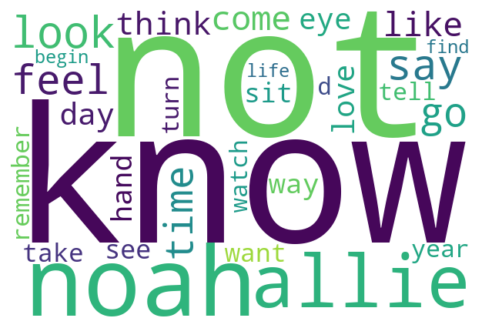

In [30]:
# Получаем 20 самых частотных слов
most_common_words = dict(Counter(word_freq).most_common(30))

# Создаем объект WordCloud
wc = WordCloud(width=600, height=400, background_color='white', max_words=100).generate_from_frequencies(most_common_words)

# Визуализируем облако слов
plt.figure(figsize=(8, 4))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

In [31]:
# сохранить датафрейм в формате csv
df_clean.to_csv('wap_lemmatized_notebook.csv', sep='\t', index=False)

In [32]:
# прочитать файл и проверить, что всё хорошо сохранилось
df1 = pd.read_csv('wap_lemmatized_notebook.csv', sep='\t')
df1

,clean
0,wonder story end
1,sun come sit window foggy breath life go m sig...
2,life not easy explain rip roaring spectacular ...
3,romantic love story cynic tragedy mind little ...
4,time unfortunately not easy stay course path s...
...,...
1025,sensitive pure
1026,come morning light soft light power
1027,awaken love sure
1028,think hear come enter room close door blacknes...


### Обучение векторной модели

In [33]:
cores = multiprocessing.cpu_count()

In [ ]:
workers = cores - 1  # Оставь одно ядро для ОС

In [36]:
fasttext_model = FastText(
    sentences=sentences,
    min_count=3,              # ← Уменьшили с 15 (иначе теряем слова)
    window=5,                 # ← Расширили контекстное окно
    vector_size=200,          # ← Вернулись к 300 (оптимально для 400K слов)
    sg=1,                     # ← Skip-gram (лучше для редких слов)
    sample=1e-3,              # ← Уменьшили (иначе теряются частые слова)
    alpha=0.025,               # ← Увеличили learning rate
    min_alpha=0.0001,         # ← Минимальный learning rate
    negative=10,              # ← Увеличили (лучше дифференциация)
    workers=workers,
    min_n=3,                  # ← Уменьшили (меньше character n-grams)
    max_n=4,
    epochs=15,                # ← Увеличили с 10
    seed=42
)

INFO - 20:20:49: collecting all words and their counts
INFO - 20:20:49: PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
INFO - 20:20:49: collected 2659 word types from a corpus of 14697 raw words and 1030 sentences
INFO - 20:20:49: Creating a fresh vocabulary
INFO - 20:20:49: FastText lifecycle event {'msg': 'effective_min_count=3 retains 929 unique words (34.94% of original 2659, drops 1730)', 'datetime': '2026-02-08T20:20:49.585027', 'gensim': '4.3.0', 'python': '3.11.6 (tags/v3.11.6:8b6ee5b, Oct  2 2023, 14:57:12) [MSC v.1935 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26200-SP0', 'event': 'prepare_vocab'}
INFO - 20:20:49: FastText lifecycle event {'msg': 'effective_min_count=3 leaves 12566 word corpus (85.50% of original 14697, drops 2131)', 'datetime': '2026-02-08T20:20:49.586505', 'gensim': '4.3.0', 'python': '3.11.6 (tags/v3.11.6:8b6ee5b, Oct  2 2023, 14:57:12) [MSC v.1935 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26200-SP0', 'event': 'prepare_vocab'}
I

In [37]:
list_sentences = list(sentences)  # иногда это помогает преобразовать обратно
print(list_sentences[:3])


[['wonder', 'story', 'end'], ['sun', 'come', 'sit', 'window', 'foggy', 'breath', 'life', 'go', 'm', 'sight', 'morning', 'shirt', 'heavy', 'pant', 'scarf', 'wrap', 'twice', 'neck', 'tuck', 'thick', 'sweater', 'knit', 'daughter', 'thirty', 'birthday', 'ago', 'thermostat', 'room', 'set', 'high', 'small', 'space', 'heater', 'sit', 'directly', 'ii', 'click', 'groan', 'spew', 'hot', 'air', 'like', 'fairy', 'tale', 'dragon', 'body', 'shiver', 'cold', 'away', 'cold', 'eighty', 'year', 'make', 'eighty', 'year', 'wonder', 'age'], ['life', 'not', 'easy', 'explain', 'rip', 'roaring', 'spectacular', 'fancied', 'burrow', 'gopher', 'suppose', 'resemble', 'blue', 'chip', 'stock', 'fairly', 'stable', 'up', 'down', 'gradually', 'trend', 'upwards', 'time', 've', 'learn', 'life', 'mislead', 'special', 'sure', 'common', 'man', 'common', 'thought', 've', 'lead', 'common', 'life', 'monument', 'dedicate', 'soon', 'forget', 've', 'love', 'heart', 'soul']]


In [38]:
t = time()

fasttext_model.build_vocab(sentences, progress_per=10000)

print('Время для построения словаря: {} мин.'.format(round((time() - t) / 60, 2)))

INFO - 20:21:07: collecting all words and their counts
INFO - 20:21:07: PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
INFO - 20:21:07: collected 2659 word types from a corpus of 14697 raw words and 1030 sentences
INFO - 20:21:07: Creating a fresh vocabulary
INFO - 20:21:07: FastText lifecycle event {'msg': 'effective_min_count=3 retains 929 unique words (34.94% of original 2659, drops 1730)', 'datetime': '2026-02-08T20:21:07.965478', 'gensim': '4.3.0', 'python': '3.11.6 (tags/v3.11.6:8b6ee5b, Oct  2 2023, 14:57:12) [MSC v.1935 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26200-SP0', 'event': 'prepare_vocab'}
INFO - 20:21:07: FastText lifecycle event {'msg': 'effective_min_count=3 leaves 12566 word corpus (85.50% of original 14697, drops 2131)', 'datetime': '2026-02-08T20:21:07.966486', 'gensim': '4.3.0', 'python': '3.11.6 (tags/v3.11.6:8b6ee5b, Oct  2 2023, 14:57:12) [MSC v.1935 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26200-SP0', 'event': 'prepare_vocab'}
I

Время для построения словаря: 0.0 мин.


In [39]:
###проверить надо ли еще раз прогружать, если сверху есть модель
t = time()

fasttext_model.train(sentences, total_examples=fasttext_model.corpus_count, epochs=25, report_delay=1)

print('Время для обучения модели: {} мин.'.format(round((time() - t) / 60, 2)))

WARNING - 20:21:10: Effective 'alpha' higher than previous training cycles
INFO - 20:21:10: FastText lifecycle event {'msg': 'training model with 11 workers on 929 vocabulary and 200 features, using sg=1 hs=0 sample=0.001 negative=10 window=5 shrink_windows=True', 'datetime': '2026-02-08T20:21:10.007270', 'gensim': '4.3.0', 'python': '3.11.6 (tags/v3.11.6:8b6ee5b, Oct  2 2023, 14:57:12) [MSC v.1935 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26200-SP0', 'event': 'train'}
INFO - 20:21:10: EPOCH 0: training on 14697 raw words (10222 effective words) took 0.1s, 173765 effective words/s
INFO - 20:21:10: EPOCH 1: training on 14697 raw words (10195 effective words) took 0.1s, 180966 effective words/s
INFO - 20:21:10: EPOCH 2: training on 14697 raw words (10212 effective words) took 0.1s, 166118 effective words/s
INFO - 20:21:10: EPOCH 3: training on 14697 raw words (10224 effective words) took 0.1s, 156268 effective words/s
INFO - 20:21:10: EPOCH 4: training on 14697 raw words (10193 effe

Время для обучения модели: 0.03 мин.


In [40]:
fasttext_model.wv.most_similar(positive=["love"])

[('lover', 0.8329466581344604),
 ('prove', 0.8090867400169373),
 ('beauty', 0.7945407032966614),
 ('local', 0.7885209321975708),
 ('mysterious', 0.7717393636703491),
 ('describe', 0.7628341913223267),
 ('beautiful', 0.759008526802063),
 ('difference', 0.7484280467033386),
 ('doubt', 0.7469292879104614),
 ('terrible', 0.743369996547699)]

In [42]:
fasttext_model.wv.most_similar(positive=["noah"])

[('noahs', 0.9204479455947876),
 ('sweet', 0.851426362991333),
 ('carefully', 0.8257230520248413),
 ('nod', 0.8061797618865967),
 ('join', 0.7995131015777588),
 ('miss', 0.7986660003662109),
 ('automatically', 0.7973166704177856),
 ('allie', 0.7967056035995483),
 ('wanted', 0.7950485944747925),
 ('coincidence', 0.7949742078781128)]

In [43]:
fasttext_model.wv.most_similar(positive=["allie"])

[('glanced', 0.8183286190032959),
 ('lie', 0.8175185322761536),
 ('daddy', 0.8119725584983826),
 ('automatically', 0.8058918118476868),
 ('noah', 0.7967056035995483),
 ('fianc', 0.7871013283729553),
 ('approach', 0.7819510698318481),
 ('adjust', 0.7701957821846008),
 ('coincidence', 0.7696153521537781),
 ('duke', 0.7695115804672241)]

### Моделирование лексико-семантического поля

In [44]:
def cluster_baseword(model, baseword, topn=50, n_clusters=6):
    """
    Выделяет ближайшие к baseword слова и кластеризует их.

    Возвращает:
    words      – список слов,
    vectors    – исходные векторы (d-мерные),
    labels     – метки кластеров (по 2D),
    vectors2d  – векторы после t-SNE (2D).
    """
    if baseword not in model.wv.key_to_index:
        print(f"{baseword} не найдено в словаре модели.")
        return None, None, None, None

    similarwords = [baseword] + [
        word for word, _ in model.wv.most_similar(baseword, topn=topn)
    ]
    words = [w for w in similarwords if w in model.wv.key_to_index]

    vectors = np.array([model.wv[w] for w in words])

    # t-SNE в 2D
    tsne = TSNE(
        n_components=2,
        random_state=42,
        perplexity=min(25, len(vectors) - 1)
    )
    vectors2d = tsne.fit_transform(vectors)

    # KMeans в 2D
    kmeans = KMeans(
        n_clusters=min(n_clusters, len(words)),
        n_init=10,
        random_state=42
    )
    labels = kmeans.fit_predict(vectors2d)

    return words, vectors, labels, vectors2d


In [26]:
def preprocess_text(text, lang='en', use_spacy=True):
    """
    Предобработка текста с поддержкой spaCy и pymorphy3
    
    Args:
        text (str): Исходный текст
        lang (str): Язык ('en' или 'ru')
        use_spacy (bool): Использовать spaCy для лемматизации (True)
                         или NLTK/pymorphy3 (False)
    
    Returns:
        list: Список лемматизированных токенов
    """
    
    # Загрузить модели один раз при первом вызове
    if use_spacy:
        if lang == 'en':
            try:
                nlp = spacy.load('en_core_web_sm')
            except:
                print("Модель en_core_web_sm не загружена. Установи: python -m spacy download en_core_web_sm")
                use_spacy = False
        elif lang == 'ru':
            try:
                nlp = spacy.load('ru_core_news_sm')
            except:
                print("Модель ru_core_news_sm не загружена. Установи: python -m spacy download ru_core_news_sm")
                use_spacy = False
    
    # Обработка текста с spaCy
    if use_spacy:
        doc = nlp(text.lower())
        lemmas = [token.lemma_ for token in doc 
                  if token.is_alpha and not token.is_stop]
        return lemmas
    
    # Альтернатива: NLTK + pymorphy3
    else:
        tokens = word_tokenize(text.lower())
        stop_words = set(stopwords.words('english')) if lang == 'en' \
                     else set(stopwords.words('russian'))
        filtered_tokens = [word for word in tokens 
                          if word.isalpha() and word not in stop_words]
        
        if lang == 'ru':
            morph = pymorphy3.MorphAnalyzer()
            lemmas = [morph.parse(word)[0].normal_form 
                     for word in filtered_tokens]
        else:
            from nltk.stem import WordNetLemmatizer
            import nltk
            lemmatizer = WordNetLemmatizer()
            pos_tags = nltk.pos_tag(filtered_tokens)
            lemmas = []
            for word, tag in pos_tags:
                pos = 'n' if tag.startswith('N') else \
                      'v' if tag.startswith('V') else \
                      'a' if tag.startswith('J') else \
                      'r' if tag.startswith('R') else 'n'
                lemmas.append(lemmatizer.lemmatize(word, pos))
        
        return lemmas

In [45]:
def analyze_text(text, lang='en', use_spacy=True):
    """Анализ текста: частотные слова, ключевые существительные и глаголы"""
    
    # Предобработка
    tokens = preprocess_text(text, lang=lang, use_spacy=use_spacy)
    
    # Частотный анализ
    freq_dist = FreqDist(tokens)
    print(f"Топ-20 частотных слов ({lang}):")
    print(freq_dist.most_common(20))
    
    # Выделение ключевых слов через spaCy (если доступен)
    if use_spacy:
        try:
            if lang == 'en':
                nlp = spacy.load('en_core_web_sm')
            else:
                nlp = spacy.load('ru_core_news_sm')
            
            doc = nlp(text.lower())
            
            nouns = [token.lemma_ for token in doc 
                    if token.pos_ == 'NOUN' and token.is_alpha and not token.is_stop]
            verbs = [token.lemma_ for token in doc 
                    if token.pos_ == 'VERB' and token.is_alpha and not token.is_stop]
            
            print(f"\nКлючевые существительные (леммы): {set(nouns[:15])}")
            print(f"Ключевые глаголы (леммы): {set(verbs[:15])}")
            
            # Дополнительно: вывести частоты глаголов и существительных
            from collections import Counter
            verb_freq = Counter(verbs).most_common(10)
            noun_freq = Counter(nouns).most_common(10)
            
            print(f"\nТоп-10 глаголов (с частотой): {verb_freq}")
            print(f"Топ-10 существительных (с частотой): {noun_freq}")
            
        except Exception as e:
            print(f"Ошибка при анализе spaCy: {e}")
    
    return tokens


In [28]:
def visualize_semantic_field(text, base_word, lang='en', use_spacy=True, topn=80):
    """
    Визуализация лексико-семантического поля слова с ускоренным t-SNE
    
    Args:
        text (str): Корпус текста
        base_word (str): Целевое слово (e.g., 'love' или 'любовь')
        lang (str): Язык ('en' или 'ru')
        use_spacy (bool): Использовать spaCy
        topn (int): Количество похожих слов
    """
    
    # Предобработка и разбиение на предложения
    print("1️⃣ Обработка текста...")
    t_start = time()
    tokens = preprocess_text(text, lang=lang, use_spacy=use_spacy)
    
    print("2️⃣ Разбиение на предложения...")
    sentences_text = re.split(r'[.!?]+', text)
    sentences = [preprocess_text(sent, lang=lang, use_spacy=use_spacy) 
                for sent in sentences_text if sent.strip()]
    
    if not sentences or len(sentences) < 2:
        print("Недостаточно предложений для обучения FastText")
        return
    
    print("3️⃣ Обучение FastText...")
    model = FastText(
        sentences=sentences,
        vector_size=300,
        window=4,
        min_count=5,
        sg=1,
        workers=4,
        epochs=10
    )
    
    print("4️⃣ Поиск похожих слов...")
    if base_word not in model.wv.key_to_index:
        print(f"❌ Слово '{base_word}' не найдено в словаре модели")
        return
    
    similar_words = [base_word] + [word for word, _ in model.wv.most_similar(base_word, topn=topn)]
    words = [word for word in similar_words if word in model.wv.key_to_index]
    vectors = np.array([model.wv[word] for word in words])
    
    print(f"5️⃣ K-means кластеризация ({len(words)} слов)...")
    kmeans = KMeans(n_clusters=min(6, len(words)), n_init=10, random_state=42)
    kmeans.fit(vectors)
    
    print("6️⃣ t-SNE визуализация (оптимизированная, это займёт 2-5 минут)...")
    t_tsne = time()
    
    # ОПТИМИЗИРОВАННЫЙ t-SNE
    tsne = TSNE(
        n_components=2, 
        random_state=42,
        perplexity=min(25, len(vectors) - 1),
        n_iter_without_progress=500,    # Уменьшено с 1000 (дефолт)
        learning_rate=200,       # Увеличено с дефолта (обычно 200)
        verbose=1,               # Показывает прогресс
        n_jobs=-1                # Параллельная обработка
    )
    vectors_2d = tsne.fit_transform(vectors)
    print(f"   ✅ t-SNE завершился за {time() - t_tsne:.2f}с")
    
    print("7️⃣ Отрисовка графика...")
    plt.figure(figsize=(16, 12))
    scatter = plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], 
                         c=kmeans.labels_, cmap='viridis', 
                         alpha=0.7, s=150, edgecolors='black', linewidth=0.5)
    
    texts = []
    for i, word in enumerate(words):
        x, y = vectors_2d[i, 0], vectors_2d[i, 1]
        txt = plt.text(x, y, word, fontsize=11, fontweight='bold',
                      bbox=dict(facecolor='white', alpha=0.8, 
                               edgecolor='gray', boxstyle='round,pad=0.4'))
        texts.append(txt)
    
    print("8️⃣ Корректировка расположения текста...")
    adjust_text(texts, arrowprops=dict(arrowstyle='->', 
                                      color='gray', lw=0.6), 
               force_points=(0.3, 0.3))
    
    plt.title(f"Лексико-семантическое поле слова '{base_word}' ({lang.upper()})", 
             fontsize=18, fontweight='bold')
    plt.xlabel("t-SNE dimension 1", fontsize=12)
    plt.ylabel("t-SNE dimension 2", fontsize=12)
    plt.colorbar(scatter, label='Кластер')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    total_time = time() - t_start
    print(f"\n✅ Всё завершилось за {total_time:.2f}с ({total_time/60:.2f} минут)")



In [43]:
def visualize_semantic_field_from_df(df_clean, base_word, lang='en',
                                     topn=80, n_clusters=6):
    """
    Визуализация лексико‑семантического поля слова base_word
    на основе df_clean['clean'].
    """
    print("1️⃣ Подготовка предложений из df_clean...")
    sentences = [
        row.split()
        for row in df_clean['clean'].astype(str)
        if isinstance(row, str) and row.strip()
    ]
    if not sentences or len(sentences) < 2:
        print("Недостаточно предложений для обучения FastText")
        return

    print(f"Всего предложений: {len(sentences)}")

    print("2️⃣ Обучение FastText...")
    t_start = time()
    model = FastText(
        sentences=sentences,
        vector_size=300,
        window=4,
        min_count=5,
        sg=1,
        workers=4,
        epochs=10,
        seed=42
    )

    print("3️⃣ Поиск похожих слов и кластеризация...")
    words, vectors, labels, vectors_2d = cluster_baseword(
        model, base_word, topn=topn, n_clusters=n_clusters
    )
    if words is None:
        return

    print("4️⃣ Отрисовка графика...")
    plt.figure(figsize=(16, 12))
    scatter = plt.scatter(
        vectors_2d[:, 0], vectors_2d[:, 1],
        c=labels, cmap='viridis',
        alpha=0.7, s=150,
        edgecolors='black', linewidth=0.5
    )

    texts = []
    for i, word in enumerate(words):
        x, y = vectors_2d[i, 0], vectors_2d[i, 1]
        txt = plt.text(
            x, y, word,
            fontsize=11, fontweight='bold',
            bbox=dict(
                facecolor='white', alpha=0.8,
                edgecolor='gray', boxstyle='round,pad=0.4'
            )
        )
        texts.append(txt)

    adjust_text(
        texts,
        arrowprops=dict(arrowstyle='->', color='gray', lw=0.6),
        force_points=(0.3, 0.3)
    )

    plt.title(
        f"Лексико‑семантическое поле слова '{base_word}' ({lang.upper()})",
        fontsize=18, fontweight='bold'
    )
    plt.xlabel("t‑SNE dimension 1", fontsize=12)
    plt.ylabel("t‑SNE dimension 2", fontsize=12)
    plt.colorbar(scatter, label='Кластер')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    total_time = time() - t_start
    print(f"\n✅ Всё завершилось за {total_time:.2f} с ({total_time/60:.2f} минут)")

In [46]:
def visualize_semantic_field_from_df(model, df_clean, base_word,
                                     lang='en', topn=80, n_clusters=6):
    """
    Визуализация лексико‑семантического поля слова base_word
    с использованием уже обученной модели FastText.
    """
    print("1️⃣ Подготовка предложений из df_clean...")
    sentences = [
        row.split()
        for row in df_clean['clean'].astype(str)
        if isinstance(row, str) and row.strip()
    ]
    if not sentences or len(sentences) < 2:
        print("Недостаточно предложений (но модель уже обучена).")

    print(f"Всего предложений (для информации): {len(sentences)}")

    print("2️⃣ Поиск похожих слов и кластеризация...")
    words, vectors, labels, vectors_2d = cluster_baseword(
        model, base_word, topn=topn, n_clusters=n_clusters
    )
    if words is None:
        return

    print("3️⃣ Отрисовка графика...")
    plt.figure(figsize=(16, 12))
    scatter = plt.scatter(
        vectors_2d[:, 0], vectors_2d[:, 1],
        c=labels, cmap='viridis',
        alpha=0.7, s=150,
        edgecolors='black', linewidth=0.5
    )

    texts = []
    for i, word in enumerate(words):
        x, y = vectors_2d[i, 0], vectors_2d[i, 1]
        txt = plt.text(
            x, y, word,
            fontsize=11, fontweight='bold',
            bbox=dict(
                facecolor='white', alpha=0.8,
                edgecolor='gray', boxstyle='round,pad=0.4'
            )
        )
        texts.append(txt)

    adjust_text(
        texts,
        arrowprops=dict(arrowstyle='->', color='gray', lw=0.6),
        force_points=(0.3, 0.3)
    )

    plt.title(
        f"Лексико‑семантическое поле слова '{base_word}' ({lang.upper()})",
        fontsize=18, fontweight='bold'
    )
    plt.xlabel("t‑SNE dimension 1", fontsize=12)
    plt.ylabel("t‑SNE dimension 2", fontsize=12)
    plt.colorbar(scatter, label='Кластер')
    plt.axis('off')
    plt.tight_layout()
    plt.show()


In [ ]:
## Не работает
# 1. Собираем весь очищенный текст в одну большую строку
text = " ".join(df_clean['clean'].astype(str))

# 2. Вызываем анализ
processed_tokens = analyze_text(text, lang='en', use_spacy=True)


1️⃣ Подготовка предложений из df_clean...
Всего предложений (для информации): 1030
2️⃣ Поиск похожих слов и кластеризация...
3️⃣ Отрисовка графика...


WARNING - 20:23:00: Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


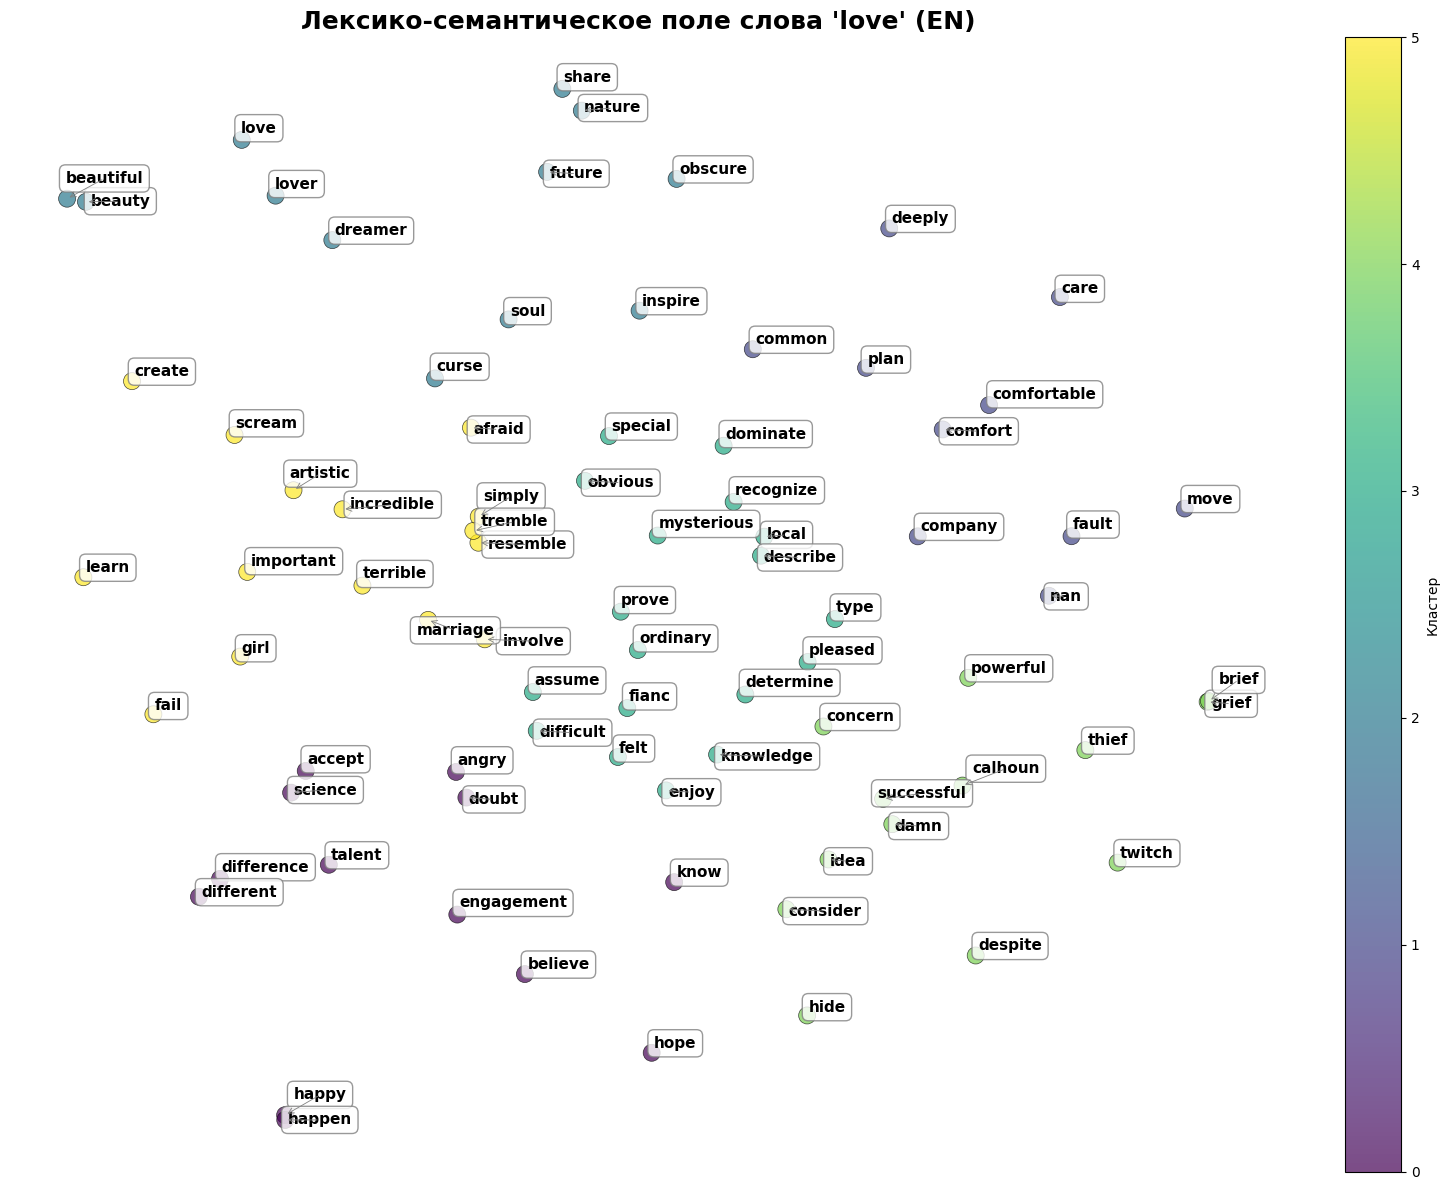

In [47]:
visualize_semantic_field_from_df(fasttext_model, df_clean, base_word='love')

1️⃣ Подготовка предложений из df_clean...
Всего предложений (для информации): 3546
2️⃣ Поиск похожих слов и кластеризация...
3️⃣ Отрисовка графика...


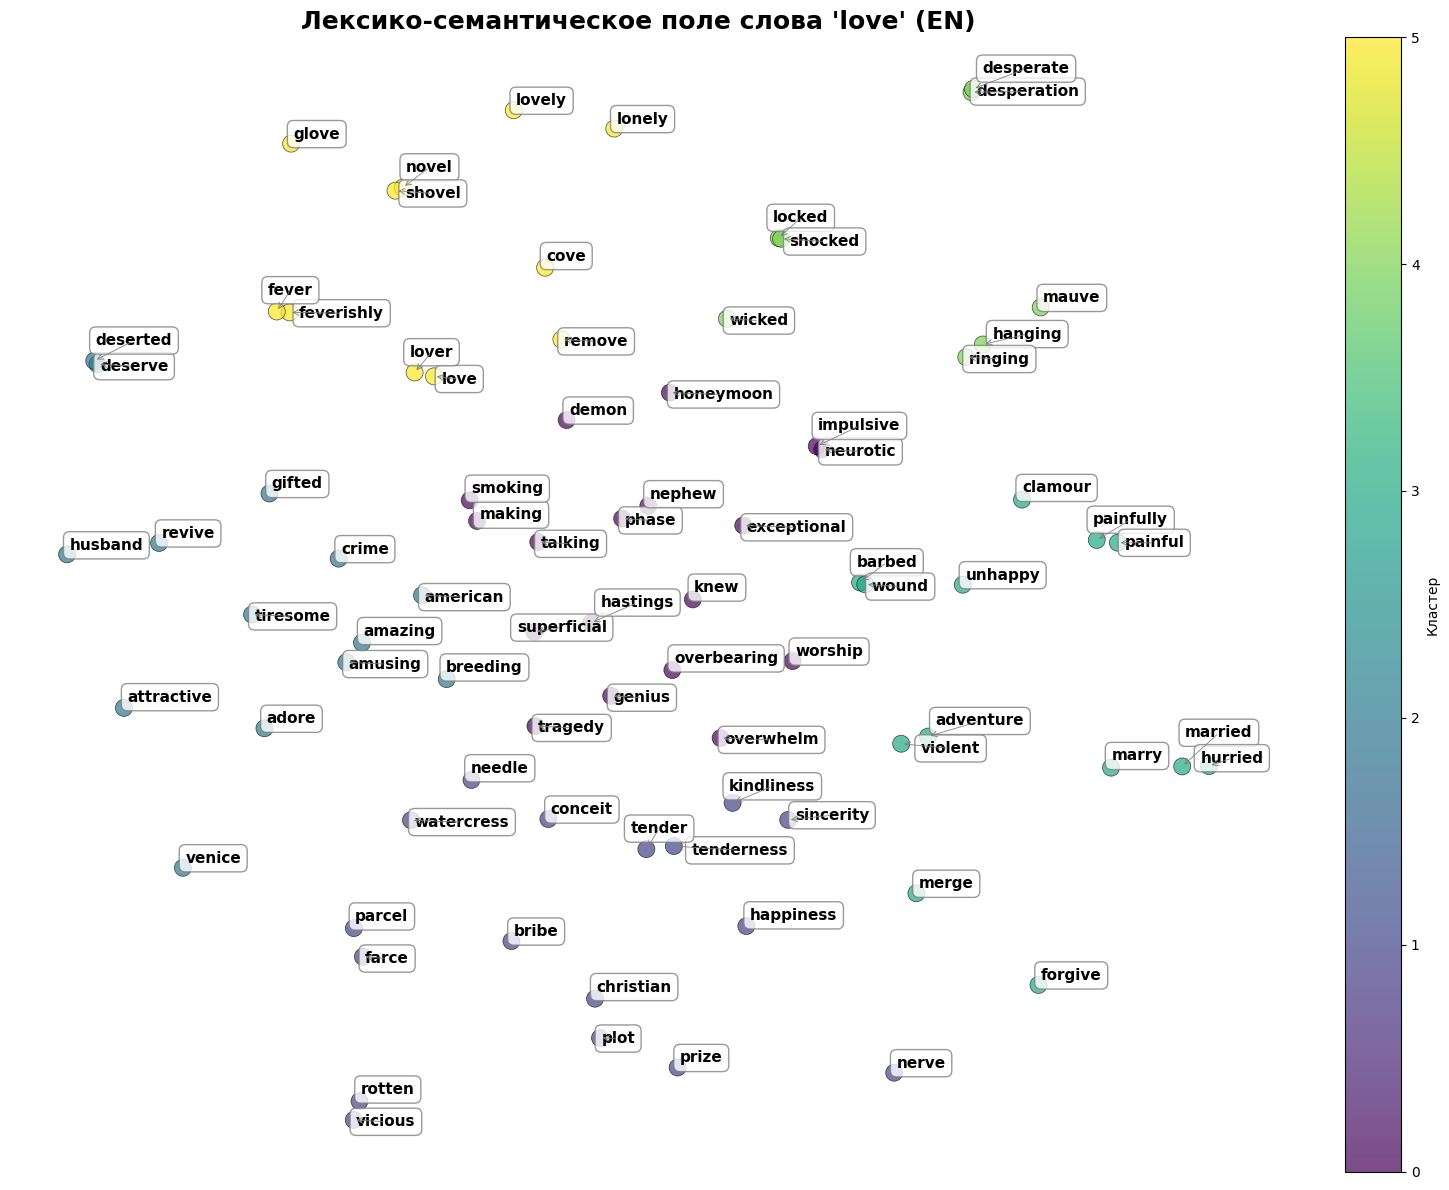

In [48]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# model – это обученный FastText (например, из visualize_semantic_field_from_df)
words, vectors, labels, vectors2d = cluster_baseword(fasttext_model, 'love', topn=80)

if words is not None:
    # Метрики считаем по тем данным, где делали кластеризацию – по vectors2d
    sil = silhouette_score(vectors2d, labels, metric='cosine')
    db  = davies_bouldin_score(vectors2d, labels)

    print(f"Silhouette score: {sil:.3f}")
    print(f"Davies-Bouldin Index: {db:.3f}")


Silhouette score: 0.025
Davies-Bouldin Index: 0.858


In [37]:
X = np.array(vectors)           # список векторов (слов / контекстов)
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(X)


In [38]:
from sklearn.metrics.pairwise import cosine_similarity

X_cos = cosine_similarity(X)  # матрица попарных сходств

cluster_sim = {}
for c in set(labels):
    idx = np.where(labels == c)[0]
    if len(idx) < 2:
        continue
    sim_mat = X_cos[np.ix_(idx, idx)]
    # среднее сходство, исключая диагональ
    mean_sim = (sim_mat.sum() - np.trace(sim_mat)) / (len(idx)*(len(idx)-1))
    cluster_sim[c] = mean_sim

print(cluster_sim)


{0: 0.4088145525027544, 1: 0.3038174203725962, 2: 0.5108730792999268, 3: 0.5089965661366781, 4: 0.6202248891194662}


1️⃣ Обработка текста...
2️⃣ Разбиение на предложения...


INFO - 21:23:58: collecting all words and their counts
INFO - 21:23:58: PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
INFO - 21:23:58: collected 5656 word types from a corpus of 56469 raw words and 3546 sentences
INFO - 21:23:58: Creating a fresh vocabulary
INFO - 21:23:58: FastText lifecycle event {'msg': 'effective_min_count=5 retains 1751 unique words (30.96% of original 5656, drops 3905)', 'datetime': '2025-11-26T21:23:58.534733', 'gensim': '4.3.0', 'python': '3.11.6 (tags/v3.11.6:8b6ee5b, Oct  2 2023, 14:57:12) [MSC v.1935 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26100-SP0', 'event': 'prepare_vocab'}
INFO - 21:23:58: FastText lifecycle event {'msg': 'effective_min_count=5 leaves 49728 word corpus (88.06% of original 56469, drops 6741)', 'datetime': '2025-11-26T21:23:58.535733', 'gensim': '4.3.0', 'python': '3.11.6 (tags/v3.11.6:8b6ee5b, Oct  2 2023, 14:57:12) [MSC v.1935 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26100-SP0', 'event': 'prepare_vocab'}


3️⃣ Обучение FastText...


INFO - 21:24:01: FastText lifecycle event {'update': False, 'trim_rule': 'None', 'datetime': '2025-11-26T21:24:01.381038', 'gensim': '4.3.0', 'python': '3.11.6 (tags/v3.11.6:8b6ee5b, Oct  2 2023, 14:57:12) [MSC v.1935 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26100-SP0', 'event': 'build_vocab'}
INFO - 21:24:01: FastText lifecycle event {'msg': 'training model with 4 workers on 1751 vocabulary and 300 features, using sg=1 hs=0 sample=0.001 negative=5 window=4 shrink_windows=True', 'datetime': '2025-11-26T21:24:01.392883', 'gensim': '4.3.0', 'python': '3.11.6 (tags/v3.11.6:8b6ee5b, Oct  2 2023, 14:57:12) [MSC v.1935 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26100-SP0', 'event': 'train'}
INFO - 21:24:01: EPOCH 0: training on 56469 raw words (43198 effective words) took 0.3s, 157794 effective words/s
INFO - 21:24:02: EPOCH 1: training on 56469 raw words (43052 effective words) took 0.3s, 157825 effective words/s
INFO - 21:24:02: EPOCH 2: training on 56469 raw words (43073 effecti

4️⃣ Поиск похожих слов...
5️⃣ K-means кластеризация (81 слов)...
6️⃣ t-SNE визуализация (оптимизированная, это займёт 2-5 минут)...
[t-SNE] Computing 76 nearest neighbors...
[t-SNE] Indexed 81 samples in 0.001s...
[t-SNE] Computed neighbors for 81 samples in 0.032s...
[t-SNE] Computed conditional probabilities for sample 81 / 81
[t-SNE] Mean sigma: 0.205577
[t-SNE] KL divergence after 250 iterations with early exaggeration: 53.913719
[t-SNE] KL divergence after 1000 iterations: 0.349496
   ✅ t-SNE завершился за 0.23с
7️⃣ Отрисовка графика...
8️⃣ Корректировка расположения текста...


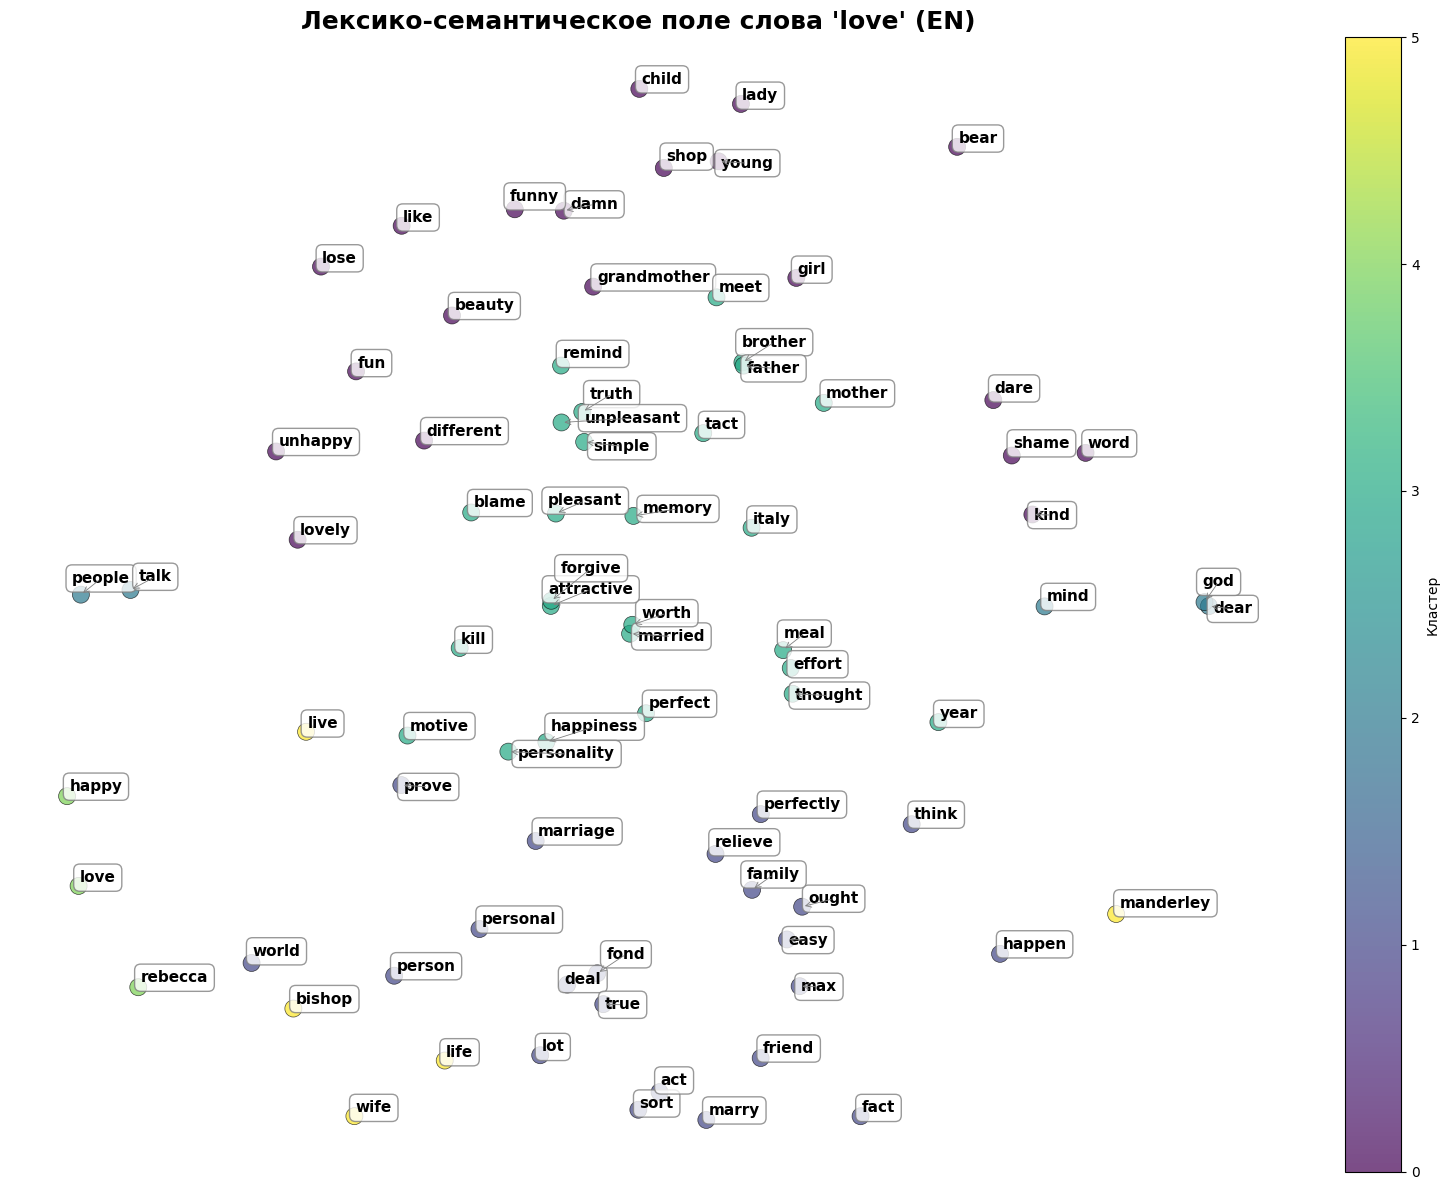


✅ Всё завершилось за 1495.28с (24.92 минут)


In [ ]:
text = '. '.join(df_clean['clean'].astype(str))  # то же, для отделения предложений
visualize_semantic_field(text, base_word='love', lang='en', use_spacy=True)

In [39]:
def visualize_semantic_field(model, base_word, topn=80):
    """
    Визуализация лексико-семантического поля слова на основе обученной FastText модели
    
    Args:
        model: обученная FastText модель
        base_word (str): Целевое слово (e.g., 'love' или 'любовь')
        topn (int): Количество похожих слов
    """
    
    print("1️⃣ Поиск похожих слов...")
    t_start = time()
    
    if base_word not in model.wv.key_to_index:
        print(f"❌ Слово '{base_word}' не найдено в словаре модели")
        return
    
    similar_words = [base_word] + [word for word, _ in model.wv.most_similar(base_word, topn=topn)]
    words = [word for word in similar_words if word in model.wv.key_to_index]
    vectors = np.array([model.wv[word] for word in words])
    
    print("2️⃣ t-SNE визуализация...")
    t_tsne = time()
    
    # ← t-SNE СНАЧАЛА, на исходных 300D векторах
    tsne = TSNE(
        n_components=2, 
        random_state=42,
        perplexity=min(25, len(vectors) - 1),
        n_iter_without_progress=500,
        learning_rate=200,
        verbose=1,
        n_jobs=-1
    )
    vectors_2d = tsne.fit_transform(vectors)  # ← Теперь vectors_2d существует!
    print(f"   ✅ t-SNE завершился за {time() - t_tsne:.2f}с")
    
    print("3️⃣ K-means кластеризация в 2D пространстве...")
    # ← Теперь кластеризуем уже в 2D
    kmeans = KMeans(n_clusters=min(6, len(words)), n_init=10, random_state=42)
    kmeans_labels = kmeans.fit_predict(vectors_2d)  # ← На 2D векторах!
    
    print("4️⃣ Отрисовка графика...")
    plt.figure(figsize=(16, 12))
    scatter = plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], 
                         c=kmeans_labels, cmap='viridis', 
                         alpha=0.7, s=150, edgecolors='black', linewidth=0.5)
    
    texts = []
    for i, word in enumerate(words):
        x, y = vectors_2d[i, 0], vectors_2d[i, 1]
        txt = plt.text(x, y, word, fontsize=11, fontweight='bold',
                      bbox=dict(facecolor='white', alpha=0.8, 
                               edgecolor='gray', boxstyle='round,pad=0.4'))
        texts.append(txt)
    
    print("5️⃣ Корректировка расположения текста...")
    adjust_text(texts, arrowprops=dict(arrowstyle='->', 
                                      color='gray', lw=0.6), 
               force_points=(0.3, 0.3))
    
    plt.title(f"Лексико-семантическое поле слова '{base_word}'", 
             fontsize=18, fontweight='bold')
    plt.xlabel("t-SNE dimension 1", fontsize=12)
    plt.ylabel("t-SNE dimension 2", fontsize=12)
    plt.colorbar(scatter, label='Кластер')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    total_time = time() - t_start
    print(f"\n✅ Визуализация завершилась за {total_time:.2f}с ({total_time/60:.2f} минут)")



1️⃣ Поиск похожих слов...
2️⃣ t-SNE визуализация...
[t-SNE] Computing 76 nearest neighbors...
[t-SNE] Indexed 81 samples in 0.001s...
[t-SNE] Computed neighbors for 81 samples in 0.017s...
[t-SNE] Computed conditional probabilities for sample 81 / 81
[t-SNE] Mean sigma: 1.523873
[t-SNE] KL divergence after 250 iterations with early exaggeration: 67.373978
[t-SNE] KL divergence after 1000 iterations: 0.748382
   ✅ t-SNE завершился за 0.34с
3️⃣ K-means кластеризация в 2D пространстве...
4️⃣ Отрисовка графика...
5️⃣ Корректировка расположения текста...


WARNING - 19:33:46: Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


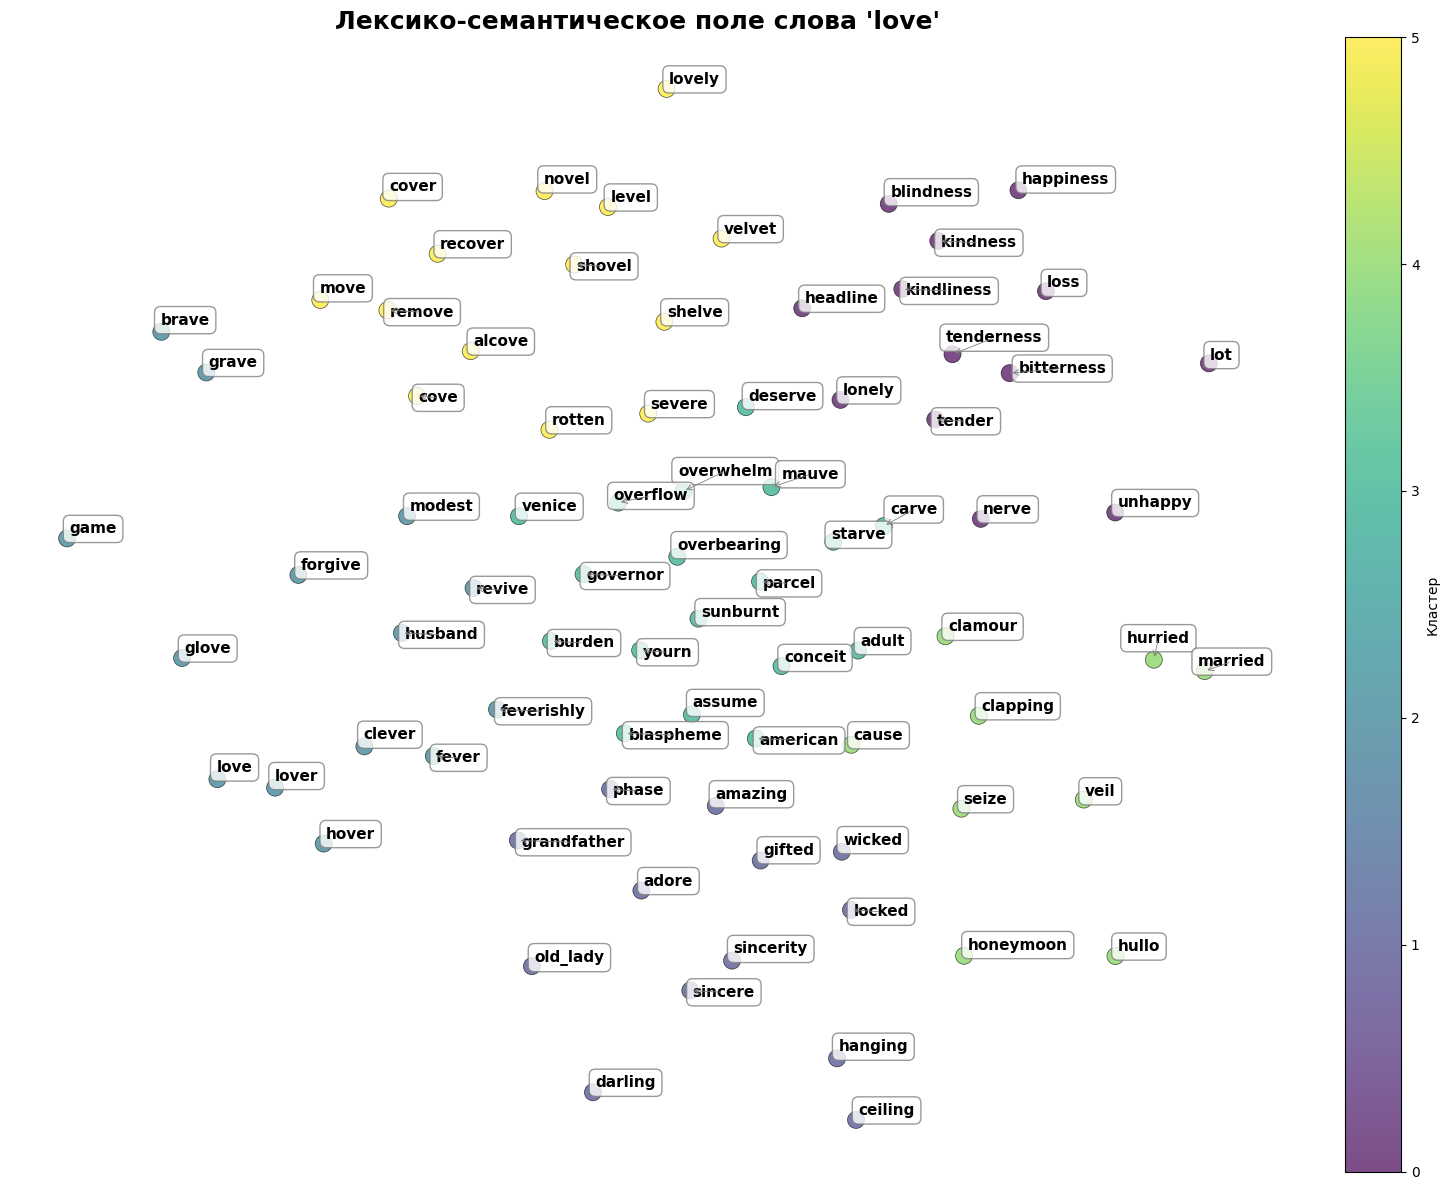


✅ Визуализация завершилась за 3.03с (0.05 минут)


In [40]:
visualize_semantic_field(fasttext_model, base_word='love', topn=80)


### Синтагматические отношения

In [47]:
def analyze_syntagmatic(text, target_word='love', window_size=3):
    # Токенизация и фильтрация знаков препинания
    tokens = [word.lower() for word in nltk.word_tokenize(text)
              if word.lower() not in string.punctuation and word.isalpha()]

    # Частеречная разметка только для слов
    tagged = pos_tag(tokens)

    # Сбор контекстов
    contexts = []
    for i, word in enumerate(tokens):
        if word == target_word:
            start = max(0, i - window_size)
            end = min(len(tokens), i + window_size + 1)
            context = tagged[start:end]
            contexts.append(context)

    # Поиск коллокаций с целевым словом
    # Используем BigramCollocationFinder напрямую на всех биграммах
    bigram_measures = BigramAssocMeasures()
    finder = BigramCollocationFinder.from_words(tokens)
    finder.apply_freq_filter(2)  # Минимум 2 вхождения
    
    # Получаем все биграммы с оценками PMI
    scored_collocations = finder.score_ngrams(bigram_measures.pmi)
    
    # Фильтруем только те, что содержат целевое слово
    target_collocations = [
        (bigram, score) for bigram, score in scored_collocations 
        if target_word in bigram
    ]
    
    # Сортируем по PMI и берем топ-20
    target_collocations.sort(key=lambda x: x[1], reverse=True)
    top_collocations = [bigram for bigram, score in target_collocations[:20]]

    # Статистика по частям речи
    pos_stats = defaultdict(int)
    for context in contexts:
        for word, pos in context:
            pos_stats[pos] += 1

    # Частотный анализ контекстных слов (без предлогов и служебных слов)
    stop_words = set(stopwords.words('russian'))
    word_freq = FreqDist()
    for context in contexts:
        for word, pos in context:
            if word != target_word and word.isalpha() and pos not in ['IN', 'TO'] and word not in stop_words:
                word_freq[word] += 1

    return {
        'collocations': top_collocations,
        'pos_context': dict(pos_stats),
        'word_context': word_freq.most_common(20)
    }

# Пример использования
result = analyze_syntagmatic(text, target_word='love')

print("Коллокации с 'love':")
print(result['collocations'])

print("\nРаспределение частей речи в контексте:")
print(result['pos_context'])

print("\nТоп-20 контекстных слов:")
print(result['word_context'])


Коллокации с 'love':
[('sign', 'love'), ('love', 'husband'), ('love', 'whisper'), ('love', 'person'), ('love', 'world'), ('love', 'rebecca'), ('love', 'love'), ('sort', 'love'), ('love', 'mr'), ('love', 'man'), ('rebecca', 'love'), ('eye', 'love'), ('maxim', 'love'), ('man', 'love'), ('think', 'love'), ('ask', 'love'), ('tell', 'love'), ('love', 'manderley'), ('frank', 'love'), ('love', 'want')]

Распределение частей речи в контексте:
{'JJ': 119, 'NN': 361, 'RB': 33, 'VBD': 16, 'VBP': 123, 'VB': 48, 'IN': 35, 'VBG': 10, 'JJR': 7, 'VBN': 8, 'MD': 1, 'NNS': 15, 'UH': 3, 'EX': 1, 'CD': 1, 'FW': 7, 'VBZ': 2, 'RP': 1}

Топ-20 контекстных слов:
[('say', 33), ('rebecca', 27), ('maxim', 18), ('know', 17), ('think', 12), ('manderley', 10), ('come', 9), ('eye', 9), ('thing', 8), ('want', 7), ('go', 7), ('man', 7), ('winter', 7), ('look', 7), ('time', 6), ('tell', 6), ('face', 6), ('marry', 5), ('frank', 5), ('forget', 5)]


In [48]:

def filter_service_words(text):
    # Токенизация и POS-теггинг
    tokens = nltk.word_tokenize(text.lower())
    tagged = pos_tag(tokens)

    # Список стоп-слов
    stop_words = set(stopwords.words('english'))  # Для английского языка

    # Фильтрация служебных частей речи и местоимений
    filtered_words = []
    for word, pos in tagged:
        if word not in stop_words and pos not in ['PRP', 'PRP$', 'WP', 'WP$']:
            filtered_words.append(word)

    return filtered_words

filtered_text = filter_service_words(text)
print(filtered_text)


['chapter', '.', 'night', 'dream', 'went', 'manderley', 'stand', 'iron', 'gate', 'lead', 'drive', 'enter', 'way', 'bar', 'padlock', 'chain', 'gate', 'call', 'dream', 'lodge', 'keeper', 'answer', 'peer', 'close', 'rust', 'spoke', 'gate', 'see', 'lodge', 'uninhabited', '.', 'smoke', 'come', 'chimney', 'little', 'lattice', 'window', 'gap', 'forlorn', 'like', 'dreamer', 'possess', 'sudden', 'supernatural', 'power', 'pass', 'like', 'spirit', 'barrier', 'drive', 'wound', 'away', 'twisting', 'turning', 'advanced', 'aware', 'change', 'come', 'narrow', 'unkempt', 'drive', 'know', 'puzzled', 'understand', 'bent', 'head', 'avoid', 'low', 'swing', 'branch', 'tree', 'realise', 'happen', 'nature', 'come', 'little', 'little', 'stealthy', 'insidious', 'way', 'encroach', 'drive', 'long', 'tenacious', 'finger', 'wood', 'menace', 'past', 'triumph', 'end', 'crowd', 'dark', 'uncontrolled', 'border', 'drive', 'beech', 'white', 'naked', 'limb', 'leant', 'close', 'branch', 'intermingle', 'strange', 'embrace',

In [49]:
import seaborn as sns

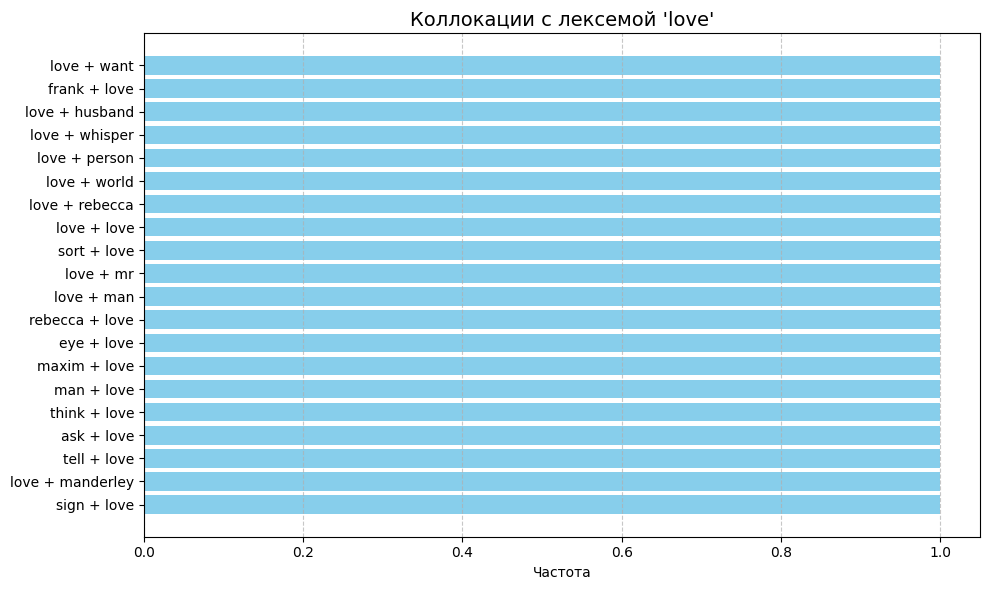

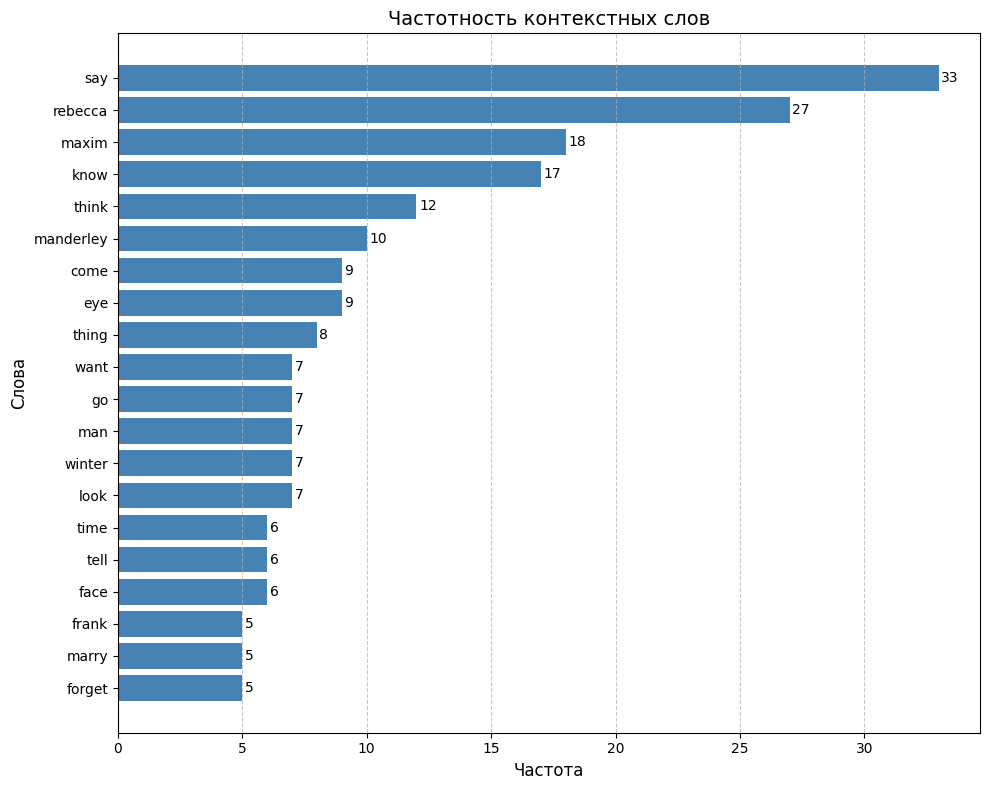

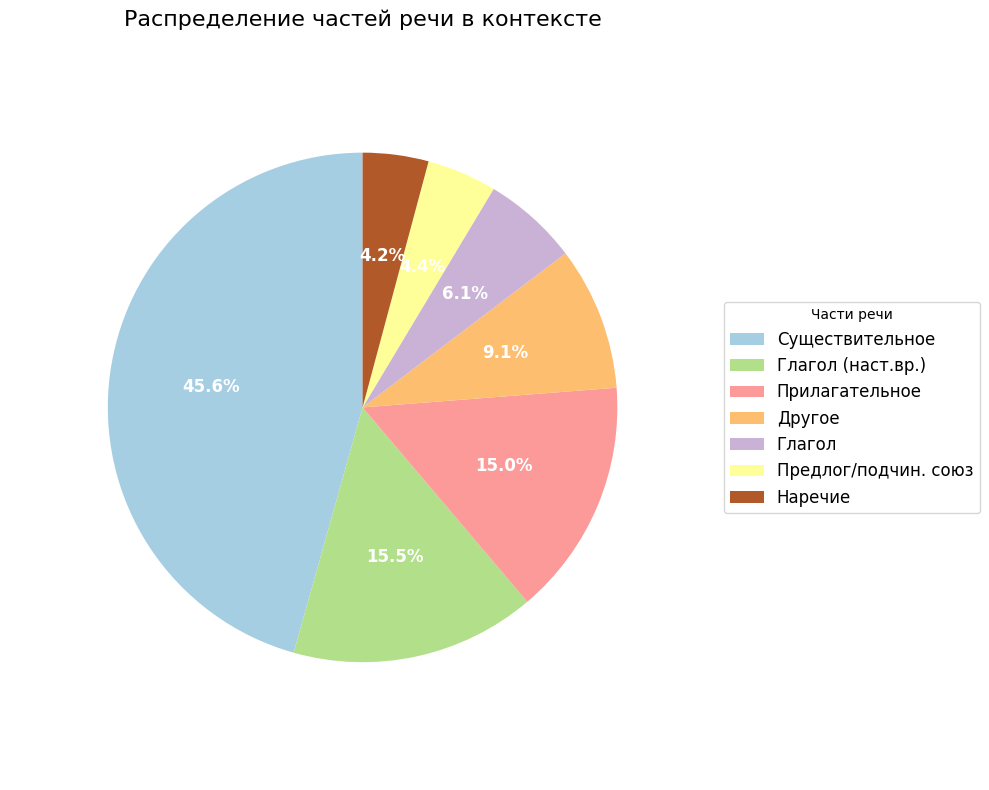


Части речи, отнесенные к категории 'Другое':
- Глагол (прош.вр.): 2.0%
- Глагол (-ing): 1.3%
- Прилагательное (сравн.): 0.9%
- Глагол (прич.прош.вр.): 1.0%
- Модальный глагол: 0.1%
- Существительные (мн.ч.): 1.9%
- UH: 0.4%
- EX: 0.1%
- Число: 0.1%
- FW: 0.9%
- Глагол (3 л. ед.ч.): 0.3%
- RP: 0.1%


In [50]:
def visualize_results(results):
    # Словарь для перевода тегов частей речи
    pos_tag_names = {
        'NN': 'Существительное',
        'NNS': 'Существительные (мн.ч.)',
        'NNP': 'Имя собственное',
        'NNPS': 'Имена собственные (мн.ч.)',
        'VB': 'Глагол',
        'VBD': 'Глагол (прош.вр.)',
        'VBG': 'Глагол (-ing)',
        'VBN': 'Глагол (прич.прош.вр.)',
        'VBP': 'Глагол (наст.вр.)',
        'VBZ': 'Глагол (3 л. ед.ч.)',
        'JJ': 'Прилагательное',
        'JJR': 'Прилагательное (сравн.)',
        'JJS': 'Прилагательное (превосх.)',
        'RB': 'Наречие',
        'RBR': 'Наречие (сравн.)',
        'RBS': 'Наречие (превосх.)',
        'DT': 'Определитель',
        'IN': 'Предлог/подчин. союз',
        'PRP': 'Личное местоимение',
        'PRP$': 'Притяж. местоимение',
        'CC': 'Сочинительный союз',
        'CD': 'Число',
        'WP': 'Вопросит. местоимение',
        'WDT': 'Вопросит. определитель',
        'TO': 'to',
        'MD': 'Модальный глагол'
    }

    # 1. Визуализация коллокаций
    plt.figure(figsize=(10, 6))
    if results['collocations']:
        colloc_data = [(c[0], c[1]) for c in results['collocations']]
        colloc_df = pd.DataFrame(colloc_data, columns=['Word1', 'Word2'])

        # Создаем строковое представление биграмм
        colloc_labels = [f"{w1} + {w2}" for w1, w2 in colloc_data]
        # Подсчитываем частоту каждой коллокации
        colloc_counts = [1] * len(colloc_labels)  # Placeholder, можно заменить на реальные частоты

        # Сортируем по частоте
        sorted_indices = np.argsort(colloc_counts)
        sorted_labels = [colloc_labels[i] for i in sorted_indices]
        sorted_counts = [colloc_counts[i] for i in sorted_indices]

        plt.barh(sorted_labels, sorted_counts, color='skyblue')
        plt.xlabel('Частота')
        plt.title("Коллокации с лексемой 'love'", fontsize=14)
        plt.grid(axis='x', linestyle='--', alpha=0.7)
    else:
        plt.text(0.5, 0.5, "Коллокации не найдены", ha='center', va='center', fontsize=14)
    plt.tight_layout()
    plt.show()

    # 2. Визуализация частотного распределения
    plt.figure(figsize=(10, 8))
    words, freqs = zip(*results['word_context'])

    # Сортировка по частоте
    sorted_indices = np.argsort(freqs)
    sorted_words = [words[i] for i in sorted_indices]
    sorted_freqs = [freqs[i] for i in sorted_indices]

    # Создаем горизонтальную диаграмму
    bars = plt.barh(sorted_words, sorted_freqs, color='steelblue')

    # Добавляем значения на график
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.1, bar.get_y() + bar.get_height()/2,
                 f'{width:.0f}', ha='left', va='center')

    plt.xlabel('Частота', fontsize=12)
    plt.ylabel('Слова', fontsize=12)
    plt.title("Частотность контекстных слов", fontsize=14)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # 3. Визуализация частеречной статистики
    plt.figure(figsize=(10, 8))

    # Группируем редкие части речи в категорию "Другое"
    pos_data = results['pos_context'].copy()
    total = sum(pos_data.values())
    threshold = 0.03  # 3% от общего количества

    # Создаем словарь с понятными названиями
    renamed_pos = {}
    other_sum = 0
    other_categories = {}  # Словарь для хранения частей речи и их процентов в "Другое"

    for pos, count in pos_data.items():
        if count/total < threshold:
            other_sum += count
            other_categories[pos_tag_names.get(pos, pos)] = count/total * 100  # Добавляем часть речи и процент в словарь
        else:
            renamed_pos[pos_tag_names.get(pos, pos)] = count

    if other_sum > 0:
        renamed_pos['Другое'] = other_sum

    # Сортируем по убыванию значений
    sorted_pos = dict(sorted(renamed_pos.items(), key=lambda item: item[1], reverse=True))

    # Выбираем цветовую палитру
    colors = plt.cm.Paired(np.linspace(0, 1, len(sorted_pos)))

    # Строим круговую диаграмму
    wedges, texts, autotexts = plt.pie(
        sorted_pos.values(),
        labels=None,  # Уберем метки на диаграмме
        autopct='%1.1f%%',
        startangle=90,
        colors=colors,
        textprops={'fontsize': 12}
    )

    # Делаем проценты внутри секторов белыми и жирными для лучшей видимости
    for i, autotext in enumerate(autotexts):
        autotext.set_color('white')
        autotext.set_fontweight('bold')

    # Добавляем легенду
    plt.legend(
        wedges,
        sorted_pos.keys(),
        title="Части речи",
        loc="center left",
        bbox_to_anchor=(1, 0, 0.5, 1),
        fontsize=12
    )

    plt.title("Распределение частей речи в контексте", fontsize=16)
    plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
    plt.tight_layout()
    plt.show()

    # Выводим список частей речи, отнесенных к "Другое", с процентами
    print("\nЧасти речи, отнесенные к категории 'Другое':")
    for category, percentage in other_categories.items():
        print(f"- {category}: {percentage:.1f}%")

# Пример использования
result = analyze_syntagmatic(text, target_word='love')
visualize_results(result)
